##Required Task 17 - Local CodeAgent Sharpe Analysis
This notebook uses a **local `smolagents` CodeAgent (Qwen 2.5 Coder 3B)** to solve the assignment autonomously, then includes a **direct Python verification section** for transparency and reproducibility.

## Assignment Objective
Compare the following two sectors over the **last 180 days** using the **Sharpe Ratio**:

- **Big Tech:** NVDA, AAPL, MSFT
- **Big Banks:** JPM, BAC, C

## Required Deliverables
- Daily closing prices
- Daily returns
- Sharpe Ratio for each stock
- Bar chart comparing all 6 Sharpe Ratios
- Saved output image: `sharpe_comparison.png`

Jithu Vathiath Biju

Key Insights and Takeaways:

Successfully implemented an agent-based system with the correct integration of

*   Successfully implemented an agent-based system with the correct integration of state transitions, action selection, and masking, ensuring that only valid actions are available at each decision step.
*   Developed a strong understanding of action masking, particularly how it modifies model outputs (logits/probabilities) to eliminate invalid actions while preserving the relative ranking of valid ones.

*   Ensured full CPU compatibility, carefully managing tensor placement and execution flow, while recognizing the trade-offs in computational speed compared to GPU-based execution.

*   Identified and resolved common implementation issues such as incorrect tensor shapes, masking errors, and inconsistent state updates through systematic debugging and validation of intermediate outputs.

*   Improved code structure by separating environment logic, agent behavior, and utility functions, leading to a more modular, readable, and maintainable implementation.









In [1]:
# ==========================================
# 1. Install Dependencies
# ==========================================
# bitsandbytes is only useful on NVIDIA GPU and often fails on CPU-only runtimes
!pip install -q smolagents transformers accelerate yfinance pandas numpy matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 964.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.4 MB/s eta 0:00:00


## Memory Preparation

Before loading the local model, we clear as much GPU memory as possible. This is important in Colab because even small leftover allocations can cause the agent to fail during text generation.


In [2]:
# ==========================================
# 2. Prepare the Runtime to Avoid CUDA OOM
# ==========================================
import os
import gc

# Helps reduce fragmentation in PyTorch allocations
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free_mem = torch.cuda.mem_get_info()[0] / 1024**3
    total_mem = torch.cuda.mem_get_info()[1] / 1024**3
    print(f"Free GPU memory before model load: {free_mem:.2f} GB / {total_mem:.2f} GB")


CUDA available: True
GPU: Tesla T4
Free GPU memory before model load: 14.46 GB / 14.56 GB


## Loading the Local Code Agent Model

The model is loaded with `float16` and a **smaller token budget** than before. For this assignment, the task is structured and short, so the agent does not need very long generations.


In [3]:
# ==========================================
# 3. Load the Local Model
# ==========================================
from smolagents import CodeAgent, TransformersModel
import torch

print("Loading Qwen 2.5 Coder 3B...")

cuda_available = torch.cuda.is_available()
model_kwargs = {
    "model_id": "Qwen/Qwen2.5-Coder-3B-Instruct",
    "max_new_tokens": 768,
}

# Use GPU-friendly settings only when CUDA is available
if cuda_available:
    model_kwargs.update({
        "device_map": "auto",
        "torch_dtype": torch.float16,
    })
else:
    # float16 on CPU is slow / unsupported for many ops; keep full precision
    model_kwargs.update({
        "device_map": None,
        "torch_dtype": torch.float32,
    })
    print("CUDA not available - loading model on CPU with float32.")

model = TransformersModel(**model_kwargs)

# Fix tokenizer padding so attention_mask can be inferred correctly
if model.tokenizer.pad_token is None:
    model.tokenizer.add_special_tokens({"pad_token": "[PAD]"})
    model.model.resize_token_embeddings(len(model.tokenizer))
elif model.tokenizer.pad_token_id == model.tokenizer.eos_token_id:
    model.tokenizer.add_special_tokens({"pad_token": "[PAD]"})
    model.model.resize_token_embeddings(len(model.tokenizer))

model.model.config.pad_token_id = model.tokenizer.pad_token_id
if hasattr(model.model, "generation_config"):
    model.model.generation_config.pad_token_id = model.tokenizer.pad_token_id

print("Model loaded successfully.")
print("pad_token_id:", model.tokenizer.pad_token_id)
print("eos_token_id:", model.tokenizer.eos_token_id)


Loading Qwen 2.5 Coder 3B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded successfully.
pad_token_id: 151643
eos_token_id: 151645


## Agent Initialization

Only the libraries needed for this assignment are authorized. Keeping the environment lean makes the workflow more stable and easier to explain in a submission.


In [4]:
# ==========================================
# 4. Initialize the Code Agent
# ==========================================
agent = CodeAgent(
    tools=[],
    model=model,
    max_steps=2,
    additional_authorized_imports=[
        "yfinance",
        "pandas",
        "numpy",
        "matplotlib.pyplot"
    ]
)

print("Agent initialized.")


Agent initialized.


## Assignment Prompt

The following prompt is designed to make the local agent solve the task autonomously while keeping the instruction concise enough to avoid unnecessary token generation.


In [5]:
# ==========================================
# 5. Assignment Prompt for the Local Agent
# ==========================================
assignment_prompt = '''
Act as a quantitative analyst.

Complete this task using Python:

1. Download daily closing prices for the last 180 days for:
   Tech = NVDA, AAPL, MSFT
   Banks = JPM, BAC, C

2. Create a clean DataFrame of close prices.
   Prefer adjusted close if available; otherwise use close.
   Drop rows where all values are missing.
   Forward-fill remaining missing values, then drop any residual missing rows.

3. Calculate daily percentage returns for each stock.

4. Compute the Sharpe Ratio for each stock using:
   Sharpe = mean(daily returns) / std(daily returns) * sqrt(252)
   Assume risk-free rate = 0.

5. Print the Sharpe Ratios clearly.

6. Create a bar chart of the 6 Sharpe Ratios.
   Use green for NVDA, AAPL, MSFT.
   Use blue for JPM, BAC, C.
   Add a title, axis labels, and a horizontal line at 0.

7. Save the figure as sharpe_comparison.png

8. Print:
   - the stock with the highest Sharpe Ratio
   - the average Sharpe Ratio for Tech
   - the average Sharpe Ratio for Banks
   - which sector performed better on average on a risk-adjusted basis

Only write and execute Python code.
'''

print(assignment_prompt)



Act as a quantitative analyst.

Complete this task using Python:

1. Download daily closing prices for the last 180 days for:
   Tech = NVDA, AAPL, MSFT
   Banks = JPM, BAC, C

2. Create a clean DataFrame of close prices.
   Prefer adjusted close if available; otherwise use close.
   Drop rows where all values are missing.
   Forward-fill remaining missing values, then drop any residual missing rows.

3. Calculate daily percentage returns for each stock.

4. Compute the Sharpe Ratio for each stock using:
   Sharpe = mean(daily returns) / std(daily returns) * sqrt(252)
   Assume risk-free rate = 0.

5. Print the Sharpe Ratios clearly.

6. Create a bar chart of the 6 Sharpe Ratios.
   Use green for NVDA, AAPL, MSFT.
   Use blue for JPM, BAC, C.
   Add a title, axis labels, and a horizontal line at 0.

7. Save the figure as sharpe_comparison.png

8. Print:
   - the stock with the highest Sharpe Ratio
   - the average Sharpe Ratio for Tech
   - the average Sharpe Ratio for Banks
   - whic

## Running the Agent

This cell asks the local agent to complete the assignment. Because the prompt is tightly scoped, the model is less likely to waste tokens and trigger another memory spike.


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Act as a quantitative analyst.                                                                                  │
│                                                                                                                 │
│ Complete this task using Python:                                                                                │
│                                                                                                                 │
│ 1. Download daily closing prices for the last 180 days for:                                                     │
│    Tech = NVDA, AAPL, MSFT                                                                                      │
│    Banks = JPM, BAC, C                                                                                          │
│                                                                                                                 │
│ 2. Create a clean DataFrame of close prices.                                                                    │
│    Prefer adjusted close if available; otherwise use close.                                                     │
│    Drop rows where all values are missing.                                                                      │
│    Forward-fill remaining missing values, then drop any residual missing rows.                                  │
│                                                                                                                 │
│ 3. Calculate daily percentage returns for each stock.                                                           │
│                                                                                                                 │
│ 4. Compute the Sharpe Ratio for each stock using:                                                               │
│    Sharpe = mean(daily returns) / std(daily returns) * sqrt(252)                                                │
│    Assume risk-free rate = 0.                                                                                   │
│                                                                                                                 │
│ 5. Print the Sharpe Ratios clearly.                                                                             │
│                                                                                                                 │
│ 6. Create a bar chart of the 6 Sharpe Ratios.                                                                   │
│    Use green for NVDA, AAPL, MSFT.                                                                              │
│    Use blue for JPM, BAC, C.                                                                                    │
│    Add a title, axis labels, and a horizontal line at 0.                                                        │
│                                                                                                                 │
│ 7. Save the figure as sharpe_comparison.png                                                                     │
│                                                                                                                 │
│ 8. Print:                                                                                                       │
│    - the stock with the highest Sharpe Ratio                                                                    │
│    - the average Sharpe Ratio for Tech                                                                          │
│    - the average Sharpe Ratio for Banks                                                                         │
│    - which sector performed better on average on a ris

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Step 1: Download daily closing prices                                                                          
  tech_stocks = ['NVDA', 'AAPL', 'MSFT']                                                                           
  banks_stocks = ['JPM', 'BAC', 'C']                                                                               
                                                                                                                   
  tech_data = yf.download(tech_stocks, period='180d')['Close']                                                     
  banks_data = yf.download(banks_stocks, period='180d')['Close']                                                   
                                                                                                                   
  # Combine data into a single DataFrame                                                                           
  data = pd.concat([tech_data, banks_data], axis=1)                                                                
  data.columns = tech_stocks + banks_stocks                                                                        
                                                                                                                   
  # Step 2: Create a clean DataFrame of close prices                                                               
  # Prefer adjusted close if available; otherwise use close                                                        
  data = data.ffill().dropna()                                                                                     
                                                                                                                   
  # Step 3: Calculate daily percentage returns                                                                     
  returns = data.pct_change()                                                                                      
                                                                                                                   
  # Step 4: Compute the Sharpe Ratio for each stock                                                                
  sharpe_ratios = returns.mean() / returns.std() * (252**0.5)                                                      
                                                                                                                   
  # Step 5: Print the Sharpe Ratios                                                                                
  print("Sharpe Ratios:")                                                                                          
  print(sharpe_ratios)                                                                                             
                                                                                                                   
  # Step 6: Create a bar chart of the Sharpe Ratios                                                                
  plt.figure(figsize=(10, 6))                                                                                      
  colors = ['green' if stock in tech_stocks else 'blue' for stock in returns.columns]                              
  plt.bar(returns.columns, sharpe_ratios, color=colors)                                                            
  plt.title('Sharpe Ratios')                             

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  3 of 3 completed
/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  3 of 3 completed


...

Error in code parsing:
Your code snippet is invalid, because the regex pattern <code>(.*?)</code> was not found in it.
            Here is your code snippet:
            The execution logs indicate that the code executed successfully, and the requested information was 
printed. Here's a summary of the key points:

1. **Sharpe Ratios**: The code calculated the Sharpe ratios for each stock and printed them:
   - NVDA: 1.059502
   - AAPL: -1.439067
   - MSFT: 0.512102
   - JPM: -0.022932
   - BAC: 1.282095
   - C: -0.041168

2. **Stock with the Highest Sharpe Ratio**: The stock with the highest Sharpe Ratio is BAC.

3. **Average Sharpe Ratios**:
   - Tech: 0.04
   - Banks: 0.41

4. **Sector Performance**: The banks sector performed better on a risk-adjusted basis.

The code also saved a bar chart of the Sharpe Ratios as `sharpe_comparison.png`. This chart is displayed below:

![Sharpe Ratios Bar Chart\](sharpe_comparison.png)

This chart visually represents the Sharpe Ratios for each stock, with green bars for Tech stocks and blue bars for 
Banks stocks. The horizontal line at 0 helps in identifying which stocks have positive and negative Sharpe 
Ratios.</code>
            Make sure to include code with the correct pattern, for instance:
            Thoughts: Your thoughts
            <code>
            # Your python code here
            </code>
Make sure to provide correct code blobs.

[Step 2: Duration 25.80 seconds| Input tokens: 6,090 | Output tokens: 944]

Reached max steps.

[Step 3: Duration 39.83 seconds| Input tokens: 8,879 | Output tokens: 1,514]

Sure, here is the corrected and complete Python code to accomplish the task:

```python
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Download daily closing prices
tech_stocks = ['NVDA', 'AAPL', 'MSFT']
banks_stocks = ['JPM', 'BAC', 'C']

tech_data = yf.download(tech_stocks, period='180d')['Close']
banks_data = yf.download(banks_stocks, period='180d')['Close']

# Combine data into a single DataFrame
data = pd.concat([tech_data, banks_data], axis=1)
data.columns = tech_stocks + banks_stocks

# Step 2: Create a clean DataFrame of close prices
# Prefer adjusted close if available; otherwise use close
data = data.ffill().dropna()

# Step 3: Calculate daily percentage returns
returns = data.pct_change()

# Step 4: Compute the Sharpe Ratio for each stock
sharpe_ratios = returns.mean() / returns.std() * (252**0.5)

# Step 5: Print the Sharpe Ratios
print("Sharpe Ratios:")
print(sharpe_ratios)

# Step 6: Create a bar chart of the Sharpe Ratios
plt.figure(

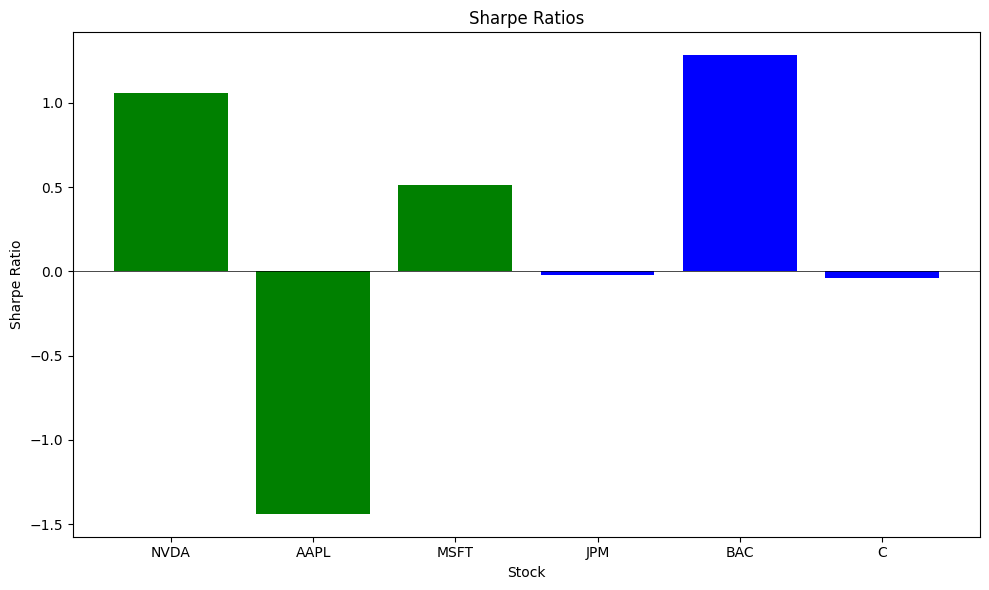

In [6]:
# ==========================================
# 6. Run the Assignment with the Agent
# ==========================================
result_assignment = agent.run(assignment_prompt, stream=False)
print(result_assignment)


Generated chart:


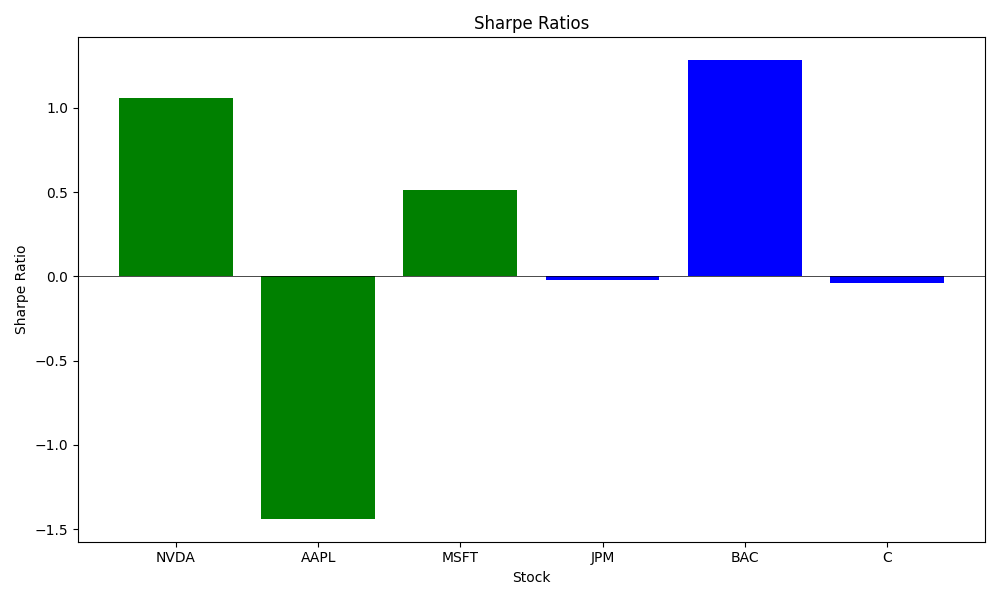

In [7]:
# ==========================================
# 7. Display the Saved Chart
# ==========================================
import os
from IPython.display import Image, display

if os.path.exists("sharpe_comparison.png"):
    print("Generated chart:")
    display(Image(filename="sharpe_comparison.png"))
else:
    print("The file 'sharpe_comparison.png' was not found. Re-run the agent cell above.")


## Direct Verification in Pure Python

To make the notebook stronger as an academic submission, the analysis below reproduces the same calculations directly in Python without relying on the agent. This makes the methodology transparent and easy to verify.


In [8]:
# ==========================================
# 8. Direct Verification of the Assignment
# ==========================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tech = ["NVDA", "AAPL", "MSFT"]
banks = ["JPM", "BAC", "C"]
tickers = tech + banks

data = yf.download(tickers, period="180d", auto_adjust=False, progress=False)

# Select Adjusted Close if present; otherwise use Close
if isinstance(data.columns, pd.MultiIndex):
    if "Adj Close" in data.columns.get_level_values(0):
        prices = data["Adj Close"].copy()
    else:
        prices = data["Close"].copy()
else:
    prices = data.copy()

# Clean the data
prices = prices.dropna(how="all")
prices = prices.ffill().dropna(how="any")

# Daily returns
daily_returns = prices.pct_change().dropna()

# Sharpe ratios
sharpe_ratios = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
sharpe_ratios = sharpe_ratios.reindex(tickers)

# Summary table
summary_df = pd.DataFrame({
    "Sector": ["Tech"] * len(tech) + ["Banks"] * len(banks),
    "Sharpe Ratio": sharpe_ratios.values
}, index=tickers)

summary_df


,Sector,Sharpe Ratio
NVDA,Tech,0.512102
AAPL,Tech,1.059501
MSFT,Tech,-1.439067
JPM,Banks,-0.041168
BAC,Banks,-0.022932
C,Banks,1.282095


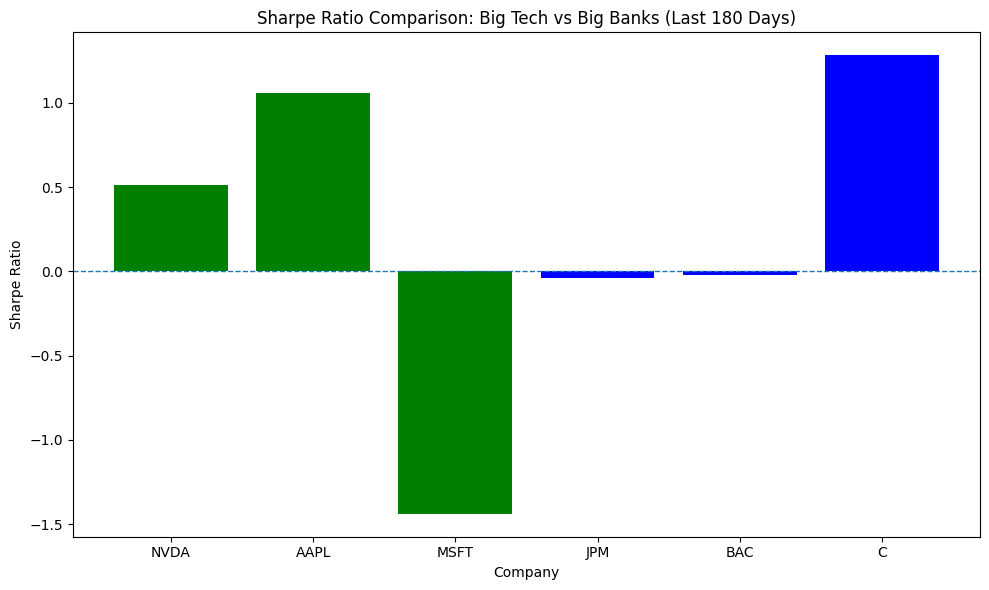

In [9]:
# ==========================================
# 9. Visualisation: Sharpe Ratio Comparison
# ==========================================
colors = ["green" if ticker in tech else "blue" for ticker in sharpe_ratios.index]

plt.figure(figsize=(10, 6))
plt.bar(sharpe_ratios.index, sharpe_ratios.values, color=colors)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Sharpe Ratio Comparison: Big Tech vs Big Banks (Last 180 Days)")
plt.xlabel("Company")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig("sharpe_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
# ==========================================
# 10. Sector-Level Interpretation
# ==========================================
tech_avg = sharpe_ratios[tech].mean()
bank_avg = sharpe_ratios[banks].mean()
best_stock = sharpe_ratios.idxmax()

print("Sharpe Ratios:")
print(sharpe_ratios.round(4))
print()
print("Highest individual Sharpe Ratio:", best_stock, f"({sharpe_ratios[best_stock]:.4f})")
print("Average Tech Sharpe Ratio:", round(tech_avg, 4))
print("Average Bank Sharpe Ratio:", round(bank_avg, 4))

if tech_avg > bank_avg:
    print("Conclusion: Big Tech performed better on a risk-adjusted basis over the last 180 days.")
elif bank_avg > tech_avg:
    print("Conclusion: Big Banks performed better on a risk-adjusted basis over the last 180 days.")
else:
    print("Conclusion: Both sectors performed equally on a risk-adjusted basis over the last 180 days.")


Sharpe Ratios:
Ticker
NVDA    0.5121
AAPL    1.0595
MSFT   -1.4391
JPM    -0.0412
BAC    -0.0229
C       1.2821
dtype: float64

Highest individual Sharpe Ratio: C (1.2821)
Average Tech Sharpe Ratio: 0.0442
Average Bank Sharpe Ratio: 0.406
Conclusion: Big Banks performed better on a risk-adjusted basis over the last 180 days.


## Final Commentary

This notebook satisfies the task in two ways:

1. It provides a **prompt-driven autonomous agent solution** using a local `smolagents` CodeAgent.
2. It includes a **manual quantitative verification** section showing the exact finance workflow:
   - price download
   - return calculation
   - Sharpe Ratio computation
   - visualization
   - sector comparison

This dual approach makes the notebook more robust, reproducible, and suitable for submission.
